In [1]:
import numpy as np
import h5py

import hpcrec

# Read HOSM results

Read the wave elevation and velocity potential at the free surface from HOSM (DNV WAMOD)

In [2]:
with h5py.File("data/hosm_output.h5", "r") as f:
    for key in ["dkx", "dx", "h", "ndim", "nx", "xdom"]:
        val = f.attrs[key].item()
        print(f"{key}: {val}")

    dk = f.attrs["dkx"].item()
    L = f.attrs["xdom"].item()
    nx = f.attrs["nx"].item()
    depth = f.attrs["h"].item()

    # Equally spaced x-grid points (peridic domain, endpoint=startpoint)
    xgrid = np.linspace(0, L, nx, endpoint=False)

    # Wave elevation at all x-grid points from WAMOD
    eta_all = f["spatial_fields"]["eta"][:]

    # Velocity potential at all x-grid points (at z=eta) from WAMOD
    psi_all = f["spatial_fields"]["psi"][:]

dkx: 0.00043981148016716576
dx: 13.951257364201572
h: 100.0
ndim: 1
nx: 1024
xdom: 14286.08754094241


In [3]:
print(eta_all.shape, psi_all.shape)
time_index = 0
eta = eta_all[time_index, :].squeeze()
psi = psi_all[time_index, :].squeeze()
print(eta.shape, psi.shape)

(2, 1024, 1) (2, 1024, 1)
(1024,) (1024,)


# Reconstruct the wave kinematics using HPC

Create a regular domain (top boundary follows the wave, lower layers blend towards the flat bottom).
The grid resolution is given by the HOSM solution in the x-direction and we select to have Nz points
in the z-direction (computing Nz by aiming for dx=dy at the free surface, if the free surface was
exactly at z=0). The bottom is always at z=-depth.

Problem statement

* Find phi, the velocity potential in the fluid domain given eta, the free surface elevation, and
  psi, the velocity potential at the free surface.
* We know the position of all boundaries (z=-depth, z=eta, x=0, x=L) so the geometry in known.
* The solution is periodic in space (x-direction), so eta(x=0) == eta(x=L) and the same for the
  velocity potential, psi
* We know the boundary condition. Top BC is Dirichlet phi=psi, left and right are periodic, bottom
  is the normal bottom boundary condition

When we have found $\phi(x,z)$ then we can find the velocity everywhere in the fluid as $\nabla \phi$

In [ ]:
from hpcrec.test_cases.wave_kinematics import (
    create_wave_domain,
    solve_wave_kinematics,
    compute_velocity,
)

# Oversample the HOSM solution to get more accurate derivatives for the velocity potential reconstruction
oversample_factor = 4  

# Construct deformed wave domain and solve for the velocity potential at all DOFs in the domain
domain = create_wave_domain(depth, xgrid, eta, oversample=oversample_factor)
phi = solve_wave_kinematics(domain, psi, oversample=oversample_factor)
print(f"Solved for {len(phi)} DOFs")

Solved for 122880 DOFs


In [14]:
# Highest crest in original data
i_crest_hosm = int(np.argmax(eta))
x_crest_hosm = xgrid[i_crest_hosm]
z_crest_hosm = eta[i_crest_hosm]
print(f"HOSM: highest crest: eta = {z_crest_hosm:.3f} m at x = {x_crest_hosm:.1f} m")

# Position of top row of the mesh
assert domain.grid_shape is not None, "Domain grid shape is not set!?"
Nx_g, Nz_g = domain.grid_shape
top_dofs = [i * (Nz_g + 1) + Nz_g for i in range(Nx_g)]
z_top = domain.dof_coordinates[top_dofs, 1]

# Highest crest in reconstructed HPC data
i_crest_hpc = int(np.argmax(z_top))
x_crest_hpc = domain.dof_coordinates[top_dofs[i_crest_hpc], 0]
z_crest_hpc = float(z_top[i_crest_hpc])
print(f"HPC : highest crest: eta = {z_crest_hpc:.3f} m at x = {x_crest_hpc:.1f} m")


HOSM: highest crest: eta = 7.601 m at x = 809.2 m
HPC : highest crest: eta = -1.562 m at x = 14282.6 m


Highest crest: eta = 7.601 m at x = 809.2 m
Max z-coordinate is -2.049 m,
  min z-coordinate is -100.000 m,
  and max horizontal velocity is 0.007 m/s,
  min horizontal velocity is -0.001 m/s


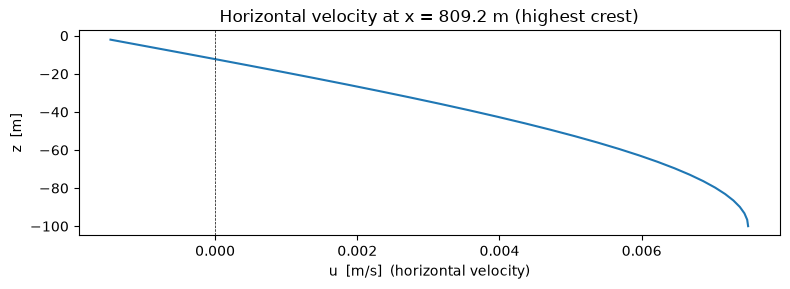

In [11]:
import matplotlib.pyplot as plt

# Find the highest wave crest
i_crest = int(np.argmax(eta))
x_crest_max = xgrid[i_crest]
crest_max = float(eta[i_crest])
print(f"Highest crest: eta = {crest_max:.3f} m at x = {x_crest_max:.1f} m")

# Collect DOFs in the crest column, ordered bottom to top
assert domain.grid_shape is not None, "Domain grid shape is not set!?"
Nx_g, Nz_g = domain.grid_shape
column_dofs = [i_crest * (Nz_g + 1) + j for j in range(Nz_g + 1)]

# Evaluate horizontal and vertical velocity at those DOFs
u, w = compute_velocity(domain, phi, dofs=column_dofs)
z_column = domain.dof_coordinates[column_dofs, 1]
print(
    f"Max z-coordinate is {np.max(z_column):.3f} m,",
    f"min z-coordinate is {np.min(z_column):.3f} m,",
    f"and max horizontal velocity is {np.max(u):.3f} m/s,",
    f"min horizontal velocity is {np.min(u):.3f} m/s",
    sep="\n  "
)

# Plot u(z) with z on the vertical axis
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(u, z_column)
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.set_xlabel("u  [m/s]  (horizontal velocity)")
ax.set_ylabel("z  [m]")
ax.set_title(f"Horizontal velocity at x = {x_crest_max:.1f} m (highest crest)")
# ax.set_ylim(-30, crest_max)
plt.tight_layout()
plt.show()